Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step - accuracy: 0.7044 - loss: 0.9223 - val_accuracy: 0.7600 - val_loss: 0.6248
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.7931 - loss: 0.4809 - val_accuracy: 0.7600 - val_loss: 0.5356
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.8276 - loss: 0.4094 - val_accuracy: 0.7400 - val_loss: 0.5052
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.8571 - loss: 0.3518 - val_accuracy: 0.7600 - val_loss: 0.4574
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.8966 - loss: 0.2636 - val_accuracy: 0.8000 - val_loss: 0.5298
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.9261 - loss: 0.2156 - val_accuracy: 0.8600 - val_loss: 0.4028
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.9606 - loss: 0.1128 - val_accuracy: 0.8600 - val_loss: 0.5141
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2

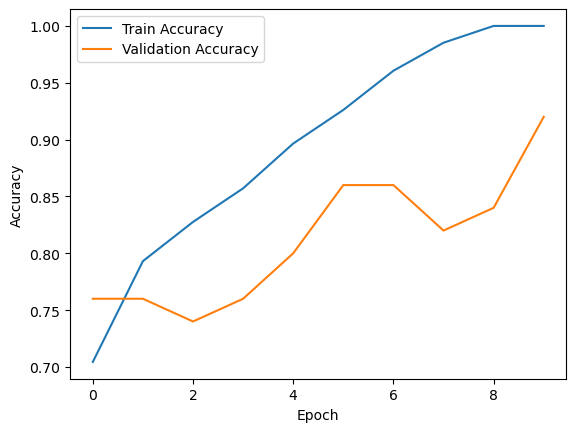

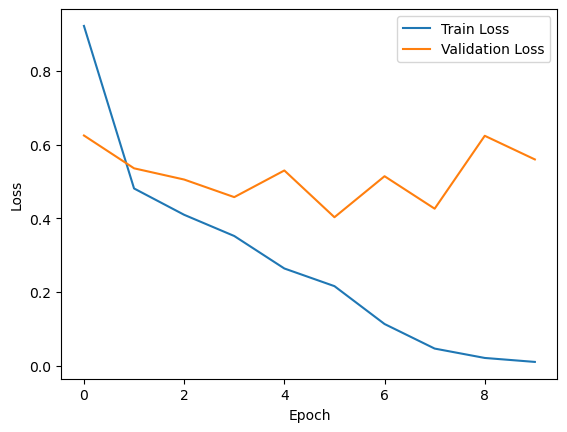

In [ ]:
import tensorflow as tf         
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator     
from tensorflow.keras import layers, models   

# Image size and batch size
img_size = 224
batch_size = 32

# Data preprocessing
train_datagen = ImageDataGenerator(
  rescale=1./255,      # [0, 1]
  vali1dation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
  "dataset/train",
  target_size=(img_size, img_size),
  batch_size=batch_size,
  class_mode='categorical',      # multi-Class
  subset='training'
)

val_generator = train_datagen.flow_from_directory(
  "dataset/train",
  target_size=(img_size, img_size),
  batch_size=batch_size,
  class_mode='categorical',
  subset='validation'
)

# CNN Model
model = models.Sequential()         

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# Compile model
model.compile(
  optimizer='adam',
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

# Train model
history = model.fit(
  train_generator,
  epochs=10,
  validation_data=val_generator
)

# Evaluate model
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
